# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [24]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [25]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- mới

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"   # không dùng nữa, xem cell Metabase bên dưới
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

Đang chạy cho: Game A (CDS) — Android — network: ['applovin', 'unity']
Khoảng ngày: 2026-08-01 -> 2026-09-17


## 1. Lấy dữ liệu Metabase

In [26]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

parameters = mb.build_parameters(
    game["metabase_card_id"],
    date_from=rc.DATE_PERIOD_START,        # "2026-07-17" — plain date, không dùng dấu ~
    date_to=rc.DATE_PERIOD_END,
    network=metabase_network_value,        # "APPLOVIN" hoặc "UNITY" — 1 giá trị, không phải list
    game=game["metabase_game"],            # "Game A" — scalar, không phải ["Game A"]
    platform=game["metabase_platform"],    # "ANDROID" — scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 314


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,CPI,ROAS D0,ROAS D3,...,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28,Revenue Complete Through
0,2026-09-17T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 AdROAS - 260131,3512.920694,3367,1.043338,0.069091,NaN,...,NaN,NaN,NaN,NaN,2.533,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
1,2026-09-17T00:00:00Z,Game A,ANDROID,UNITY,CDS Android - D28 AdROAS - 260527,1264.377891,3069,0.411984,0.060110,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
2,2026-09-17T00:00:00Z,Game A,ANDROID,UNITY,CDS Android - D28 BLDROAS - 260723,877.090276,714,1.228418,0.163206,NaN,...,NaN,NaN,NaN,NaN,10.587,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
3,2026-09-17T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 BLDROAS - 260406,759.454623,368,2.063735,0.042096,NaN,...,NaN,NaN,NaN,NaN,9.406,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
4,2026-09-17T00:00:00Z,Game A,ANDROID,APPLOVIN,CDS Android - D28 AdROAS - 260916 - CPM,507.881201,89,5.706530,0.107900,NaN,...,NaN,NaN,NaN,NaN,3.063,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [27]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 314
Totals: {'installs': 438369.0, 'network_cost': 704054.1894, 'roas_cal_d0': 0.0643, 'roas_cal_d3': 0.1996, 'roas_cal_d7': 0.2923, 'roas_cal_d14': 0.383, 'roas_cal_d28': 0.5001, 'ad_revenue_total_cal_d0': 44348.7764, 'ad_revenue_total_cal_d3': 137237.6767, 'ad_revenue_total_cal_d7': 193015.0249, 'ad_revenue_total_cal_d14': 225454.19, 'ad_revenue_total_cal_d28': 218208.271, 'revenue_total_cal_d0': 951.766, 'revenue_total_cal_d3': 3316.643, 'revenue_total_cal_d7': 5522.156, 'revenue_total_cal_d14': 7743.746, 'revenue_total_cal_d28': 8915.446}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-08-10,ALV,CDS Android - D28 AdROAS - 260131,7345,13013.1837,0.0524,0.1815,0.2812,0.3761,0.4765,679.5212,2301.4237,3538.578,4659.4193,5895.8504,2.0,61.075,120.768,235.154,305.131
1,2026-08-23,ALV,CDS Android - D28 AdROAS - 260131,7268,11671.3457,0.0663,0.1846,0.287,0.3862,0.5143,771.9509,2137.9044,3309.1723,4451.7325,5911.9935,2.358,16.606,40.705,55.345,90.658
2,2026-08-09,ALV,CDS Android - D28 AdROAS - 260131,7000,9302.7548,0.0643,0.1941,0.2985,0.412,0.5404,571.8591,1767.1511,2706.7655,3712.3175,4866.6778,26.547,38.503,70.29,120.869,160.763
3,2026-08-08,ALV,CDS Android - D28 AdROAS - 260131,6850,10180.8703,0.0647,0.216,0.319,0.4283,0.5396,647.0559,2174.8905,3208.0468,4294.1233,5410.6843,11.156,24.636,39.148,66.536,83.185
4,2026-08-19,ALV,CDS Android - D28 AdROAS - 260131,6637,8304.7174,0.0587,0.2009,0.2954,0.3897,0.4872,484.4959,1650.1333,2427.5995,3207.9177,4002.1813,3.092,18.04,25.565,28.153,44.211


## 3. Normalize + loại ngày lỗi + Merge

In [28]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 313 dòng
Chỉ có ở Metabase: 1 dòng
Chỉ có ở Adjust: 1 dòng

⚠️ Chỉ có ở Metabase:
           date Campaign   Network
247  2026-09-07           APPLOVIN

⚠️ Chỉ có ở Adjust:
           date campaign_network network
251  2026-09-07          unknown     ALV


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [29]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-17
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 5355 dòng (= 315 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 966


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-01,APPLOVIN,CDS Android - D28 AdROAS - 260131,AD_REVENUE_D0,47,False,952.308121,962.9208,-10.612679,0.988979,-1.1021,OK
1,2026-08-01,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D0,47,False,63.615797,63.5168,0.098997,1.001559,0.1559,OK
2,2026-08-01,APPLOVIN,CDS Android - D28 BLDROAS - 260406,AD_REVENUE_D0,47,False,699.233728,706.9195,-7.685772,0.989128,-1.0872,OK
3,2026-08-01,UNITY,CDS Android - D28 AdROAS - 260527,AD_REVENUE_D0,47,False,210.530060,211.2801,-0.750040,0.996450,-0.3550,OK
4,2026-08-01,UNITY,CDS Android - D28 BLDROAS - 260723,AD_REVENUE_D0,47,False,50.455878,50.5612,-0.105322,0.997917,-0.2083,OK
5,2026-08-01,UNITY,CDS Android - D7 AdROAS - 260529 - V8/PA4,AD_REVENUE_D0,47,False,0.000000,0.0000,NaN,NaN,NaN,"N/A (adjust = 0, không chia được)"
6,2026-08-01,UNITY,CDS Android - D7 BLDROAS - 260723,AD_REVENUE_D0,47,False,60.222954,60.2230,-0.000046,0.999999,-0.0001,OK
7,2026-08-01,APPLOVIN,CDS Android - D28 AdROAS - 260131,AD_REVENUE_D14,47,False,4939.569805,5059.6518,-120.081995,0.976267,-2.3733,OK
8,2026-08-01,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D14,47,False,163.451995,163.3327,0.119295,1.000730,0.0730,OK
9,2026-08-01,APPLOVIN,CDS Android - D28 BLDROAS - 260406,AD_REVENUE_D14,47,False,4579.272956,4646.4484,-67.175444,0.985543,-1.4457,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [30]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                                    campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
           CDS Android - D28 AdROAS - 260131         ROAS_D0       48         0.0020      0.9700                 3.0023                   2.6449                4.1619           4.1667
           CDS Android - D28 AdROAS - 260131         ROAS_D3       45         0.0064      0.9700                 3.0027                   2.9961                4.3296           2.2222
           CDS Android - D28 AdROAS - 260131         ROAS_D7       41         0.0097      0.9685                 3.1477                   3.0791                4.3564           0.0000
           CDS Android - D28 AdROAS - 260131        ROAS_D14       34         0.0135      0.9667                 3.3348                   3.5338                4.4857           0.0000
           CDS Android - D28 AdROAS - 260131

In [31]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [32]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
1390,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D28,0.0,0.0152,-0.0152,-100.0
1402,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D7,0.0,0.0152,-0.0152,-100.0
1396,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D3,0.0,0.0152,-0.0152,-100.0
1456,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D14,0.0,0.0316,-0.0316,-100.0
1450,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D0,0.0,0.0316,-0.0316,-100.0
1462,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D28,0.0,0.0316,-0.0316,-100.0
1384,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D14,0.0,0.0152,-0.0152,-100.0
1468,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D3,0.0,0.0316,-0.0316,-100.0
1474,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D7,0.0,0.0316,-0.0316,-100.0
1378,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D0,0.0,0.0152,-0.0152,-100.0



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
3859,2026-09-03,APPLOVIN,CDS Android - D28 AdROAS - 260131,AD_REVENUE_D0,274.286016,307.6453,-33.359284,-10.8434
3919,2026-09-03,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D0,0.060935,0.0683,-0.007365,-10.7829
3874,2026-09-03,APPLOVIN,CDS Android - D28 AdROAS - 260131,AD_REVENUE_D3,856.577607,907.4117,-50.834093,-5.6021
3934,2026-09-03,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D3,0.191535,0.2027,-0.011165,-5.5079
1563,2026-08-14,APPLOVIN,CDS Android - D28 AdROAS - 260131,ROAS_D0,0.059664,0.0630,-0.003336,-5.2945
136,2026-08-02,UNITY,CDS Android - D28 AdROAS - 260527,AD_REVENUE_D28,1257.482194,1323.7854,-66.303206,-5.0086
1390,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D28,0.000000,0.0152,-0.015200,-100.0000
1402,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D7,0.000000,0.0152,-0.015200,-100.0000
1396,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,AD_REVENUE_D3,0.000000,0.0152,-0.015200,-100.0000
1456,2026-08-13,APPLOVIN,CDS Android - D28 AdROAS - CPM - 260727,ROAS_D14,0.000000,0.0316,-0.031600,-100.0000


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [33]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_a_android


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  43336.705789    44348.6186 305     -2.281723
    AD_REVENUE_D3 130378.701130   133547.1266 288     -2.372515
    AD_REVENUE_D7 179084.259965   183638.5199 265     -2.480013
   AD_REVENUE_D14 207165.486333   212639.8804 229     -2.574491
   AD_REVENUE_D28 183372.469697   188217.5215 139     -2.574177
   IAP_REVENUE_D0    951.766000      951.7660 104      0.000000
   IAP_REVENUE_D3   3225.115000     3225.1150 151      0.000000
   IAP_REVENUE_D7   5413.066000     5413.0660 152      0.000000
  IAP_REVENUE_D14   7137.879000     7137.8790 131      0.000000
  IAP_REVENUE_D28   8128.098000     8128.0980  87      0.000000
             COST 704054.207282   704054.1890 312      0.000003
         INSTALLS 438227.000000   438368.0000 312     -0.032165
 TOTAL_REVENUE_D0  29225.905813    29937.3805 104     -2.376543
 TOTAL_REVENUE_D3 116402.605611   119359.6804 151   

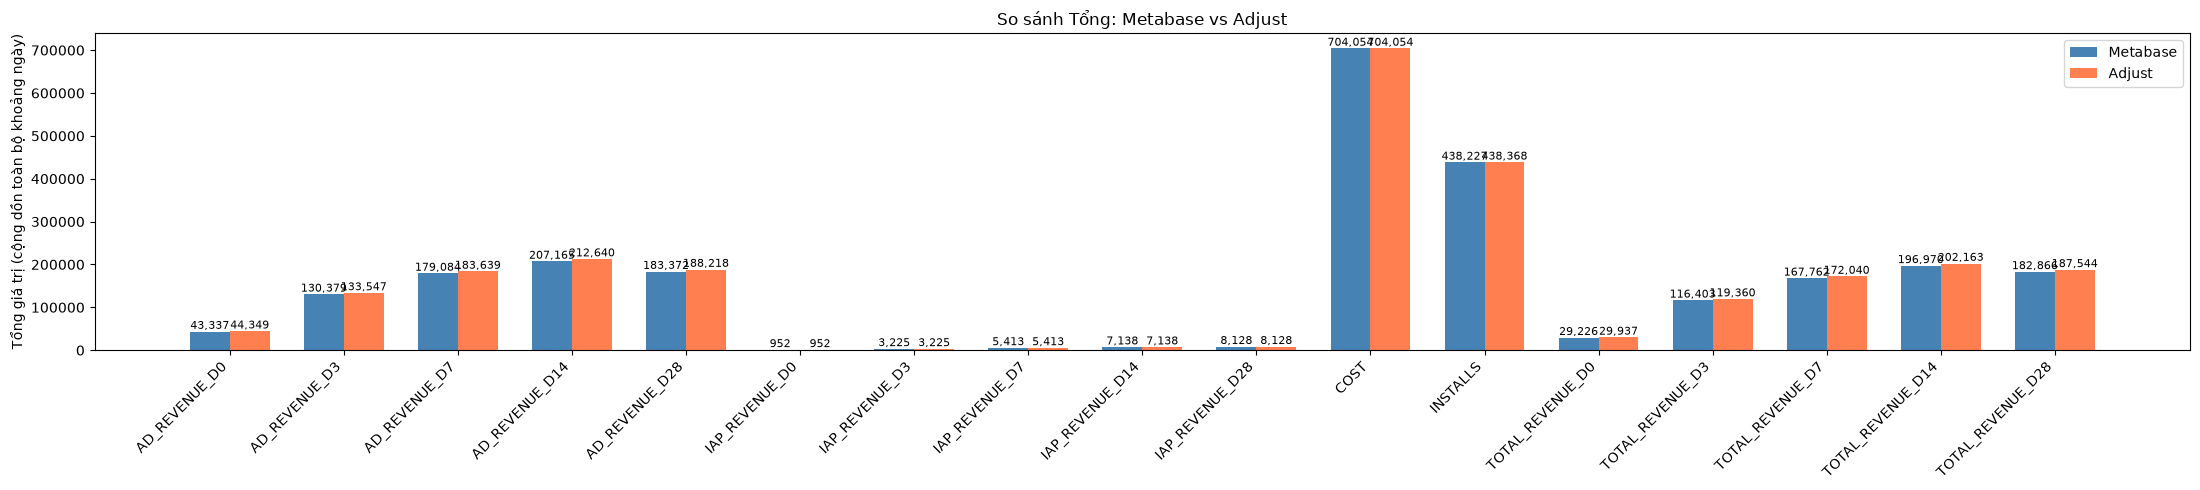

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_a_android\reconciliation_totals_comparison.csv


In [34]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [35]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [36]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 13
                                              n_days  first_date   last_date
campaign                                                                    
CDS Android - D28 AdROAS - 260131                 48  2026-08-01  2026-09-17
CDS Android - D28 AdROAS - 260527                 48  2026-08-01  2026-09-17
CDS Android - D28 BLDROAS - 260406                48  2026-08-01  2026-09-17
CDS Android - D28 BLDROAS - 260723                48  2026-08-01  2026-09-17
CDS Android - D28 AdROAS - Localize - 260813      32  2026-08-17  2026-09-17
CDS Android - D28 AdROAS - CPM - 260727           30  2026-08-01  2026-08-30
CDS Android - D7 BLDROAS - 260723                 23  2026-08-01  2026-08-23
CDS Android - D28 AdROAS - Weekend - 260724       22  2026-08-07  2026-08-29
CDS Android - D28 AdROAS - 260904 - PA             9  2026-09-08  2026-09-17
CDS Android - D7 AdROAS - 260529 - V8/PA4          3  2026-08-01  2026-08-03
CDS Android - D28 AdROAS - 260916 - CPM

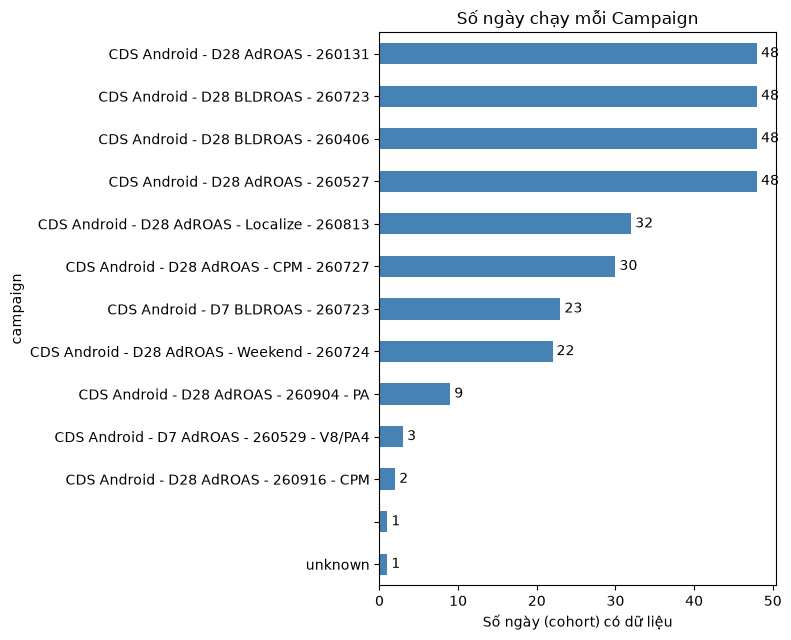

In [37]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

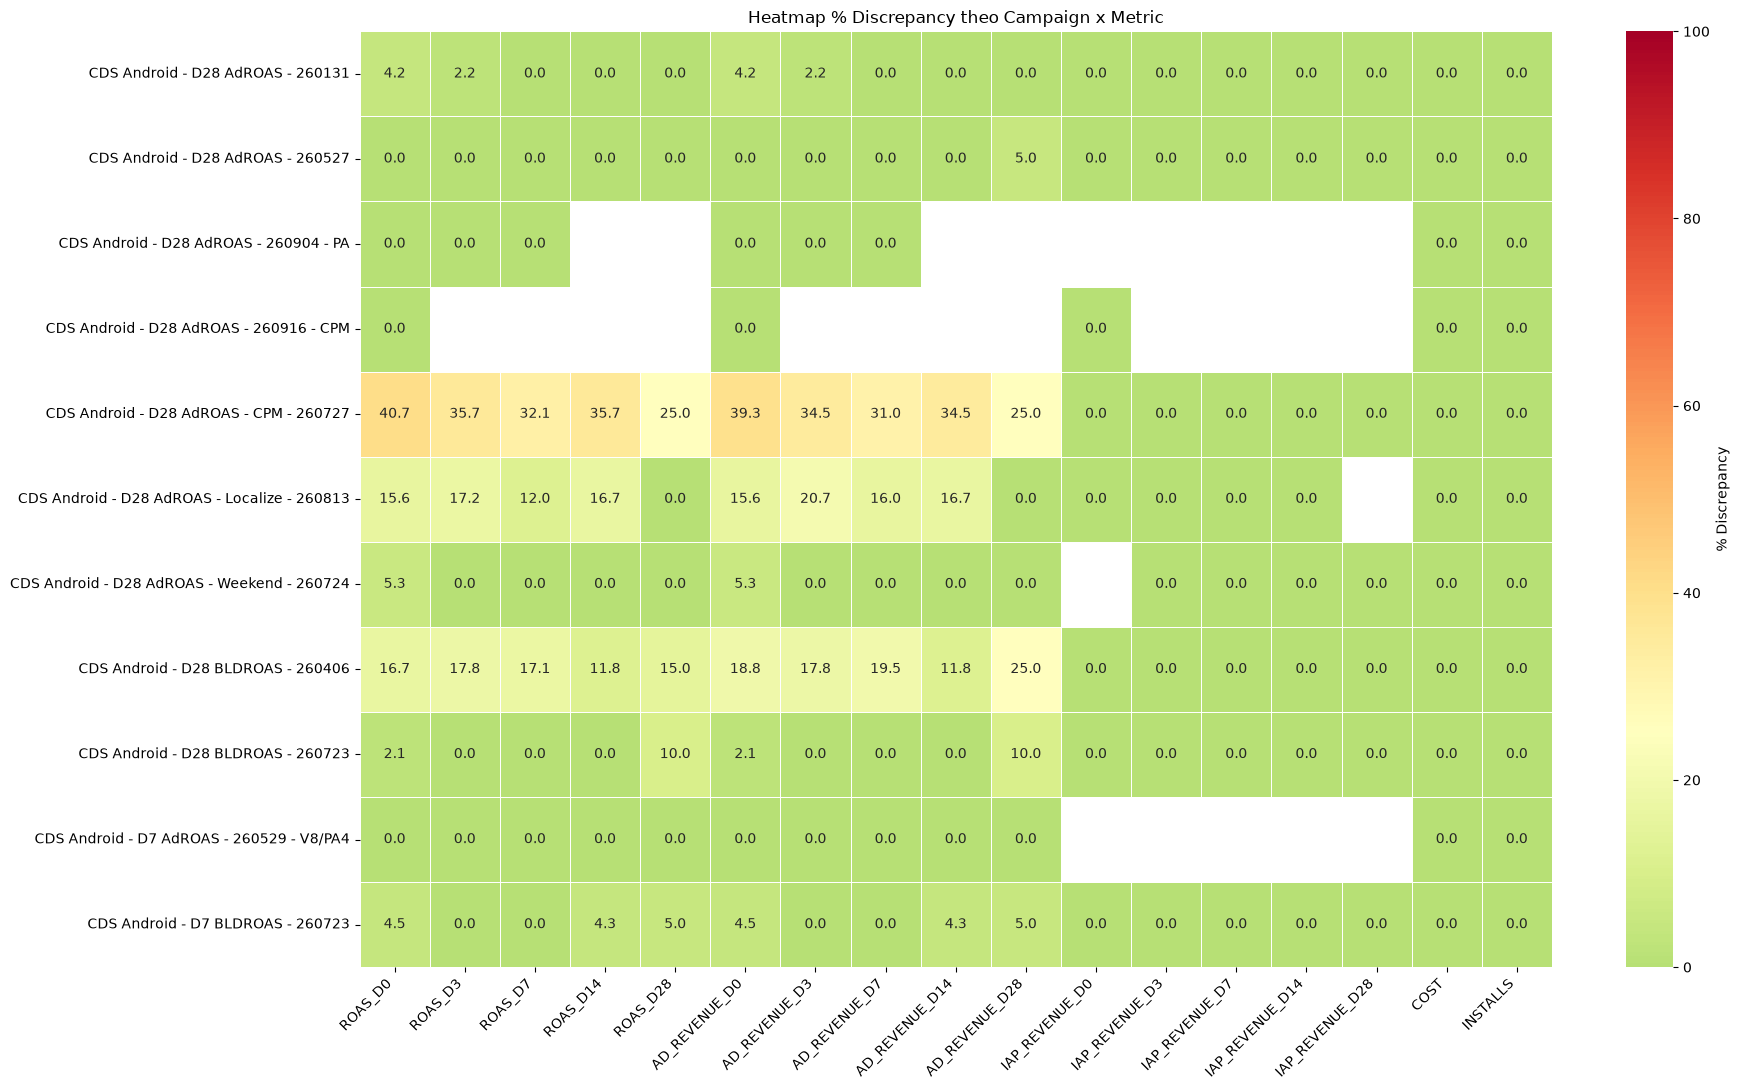

In [38]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

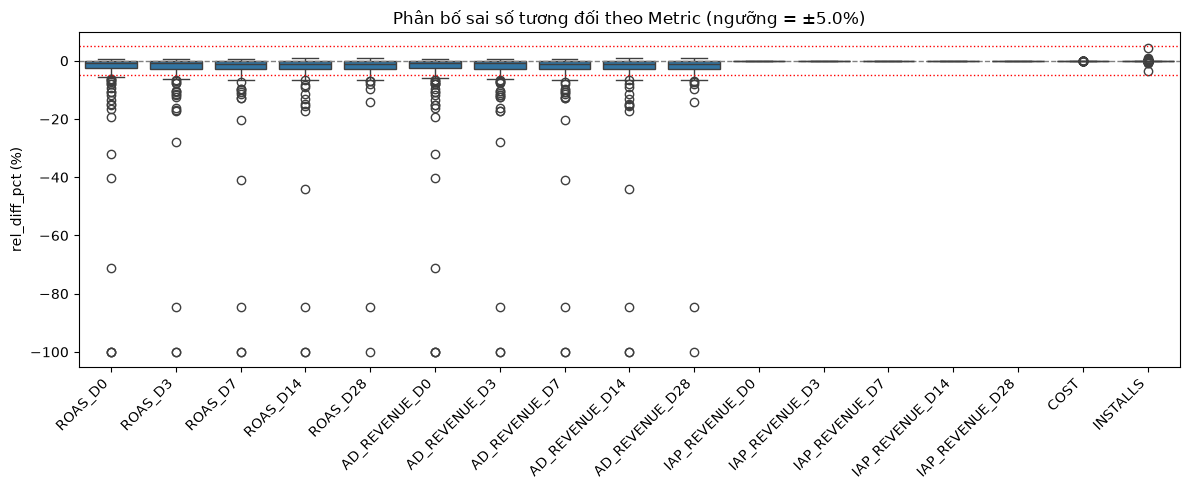

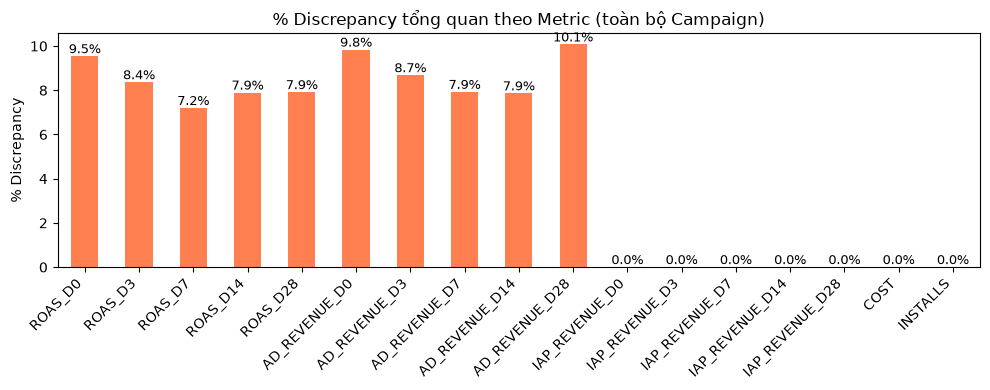

In [39]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

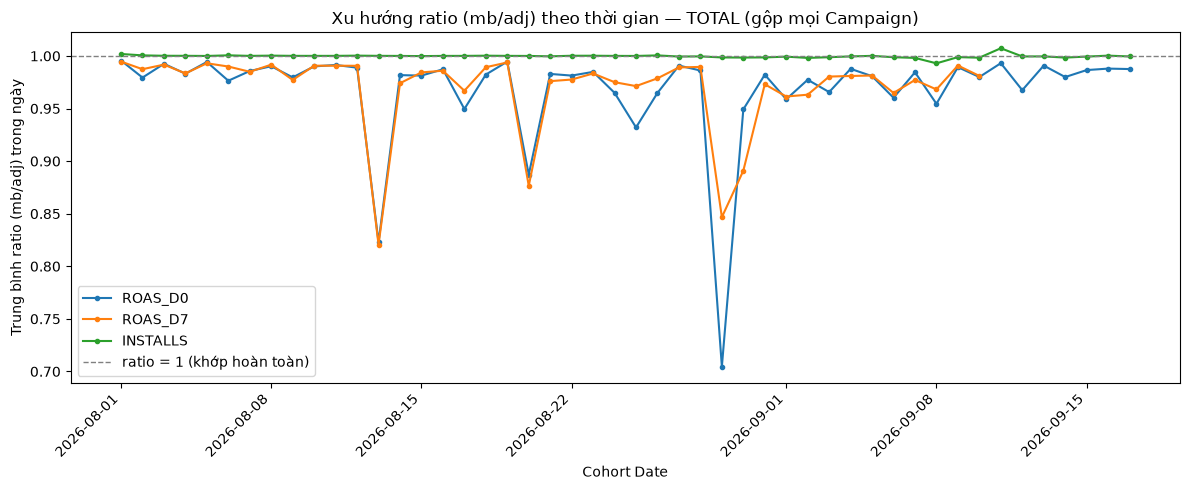

⚠️ CẢNH BÁO: đang vẽ 11 campaign cùng lúc, biểu đồ có thể rối. Cân nhắc truyền `campaigns=[...]` để giới hạn lại.


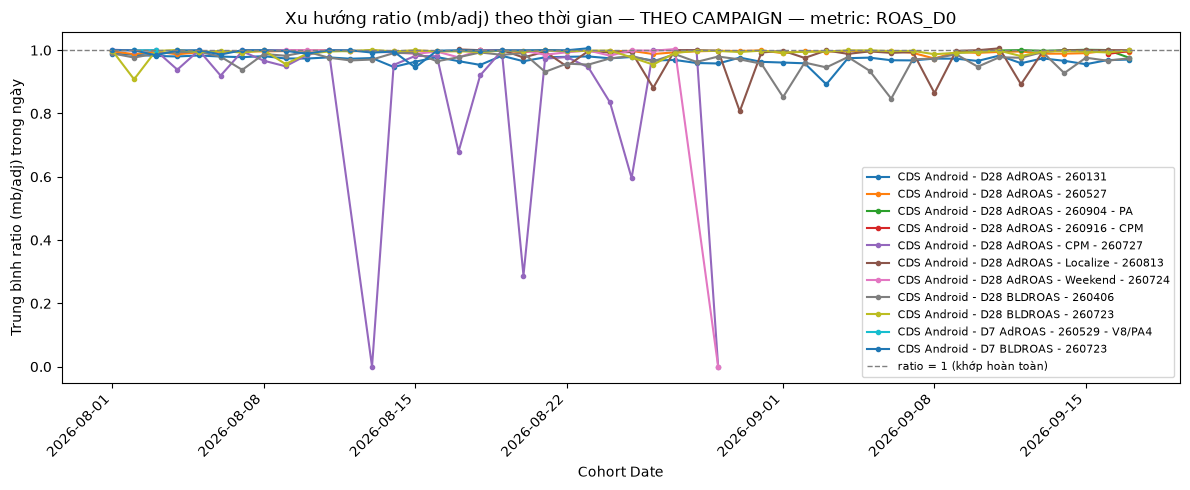

⚠️ CẢNH BÁO: đang vẽ 9 campaign cùng lúc, biểu đồ có thể rối. Cân nhắc truyền `campaigns=[...]` để giới hạn lại.


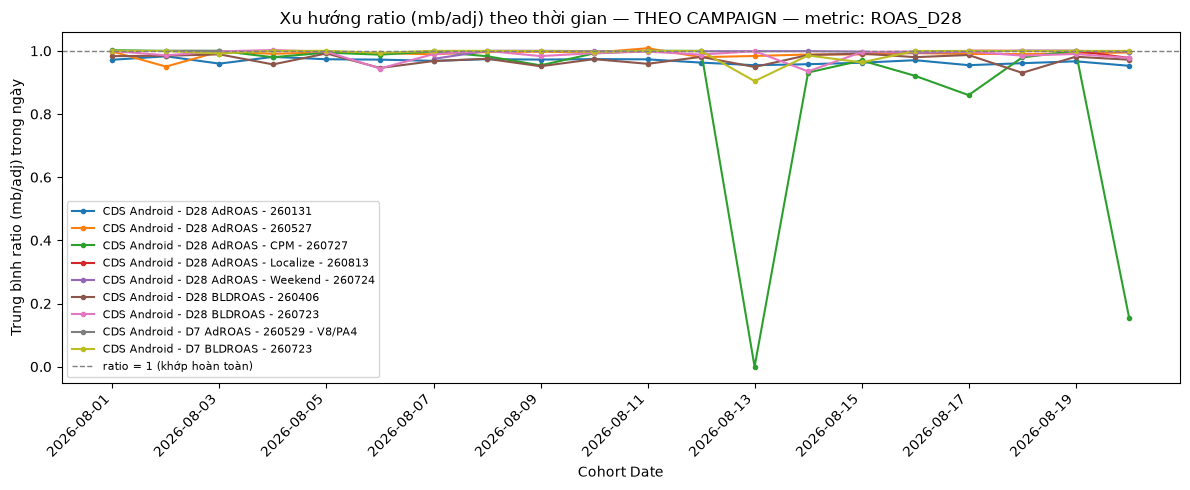

⚠️ CẢNH BÁO: đang vẽ 11 campaign cùng lúc, biểu đồ có thể rối. Cân nhắc truyền `campaigns=[...]` để giới hạn lại.


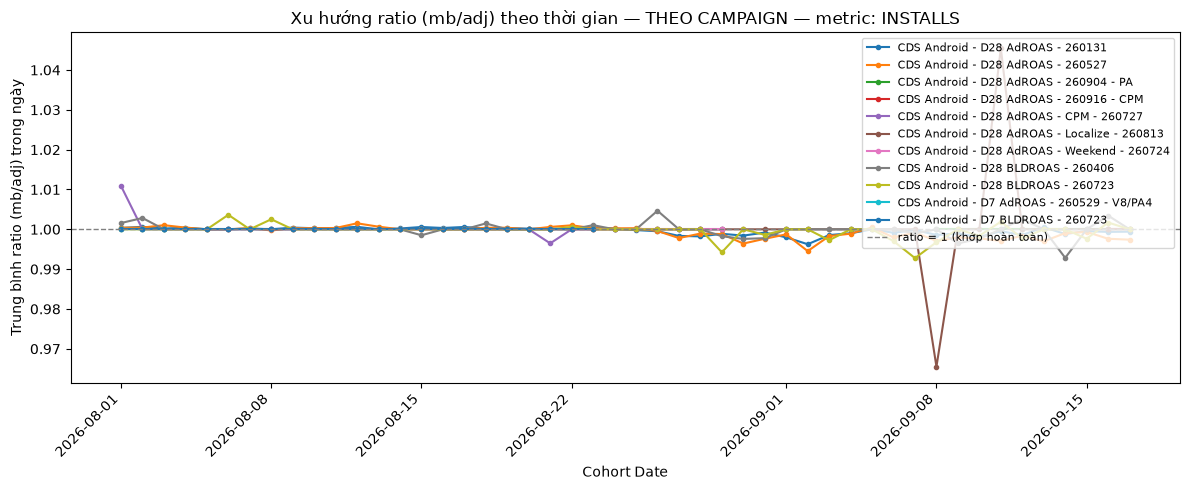

In [40]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

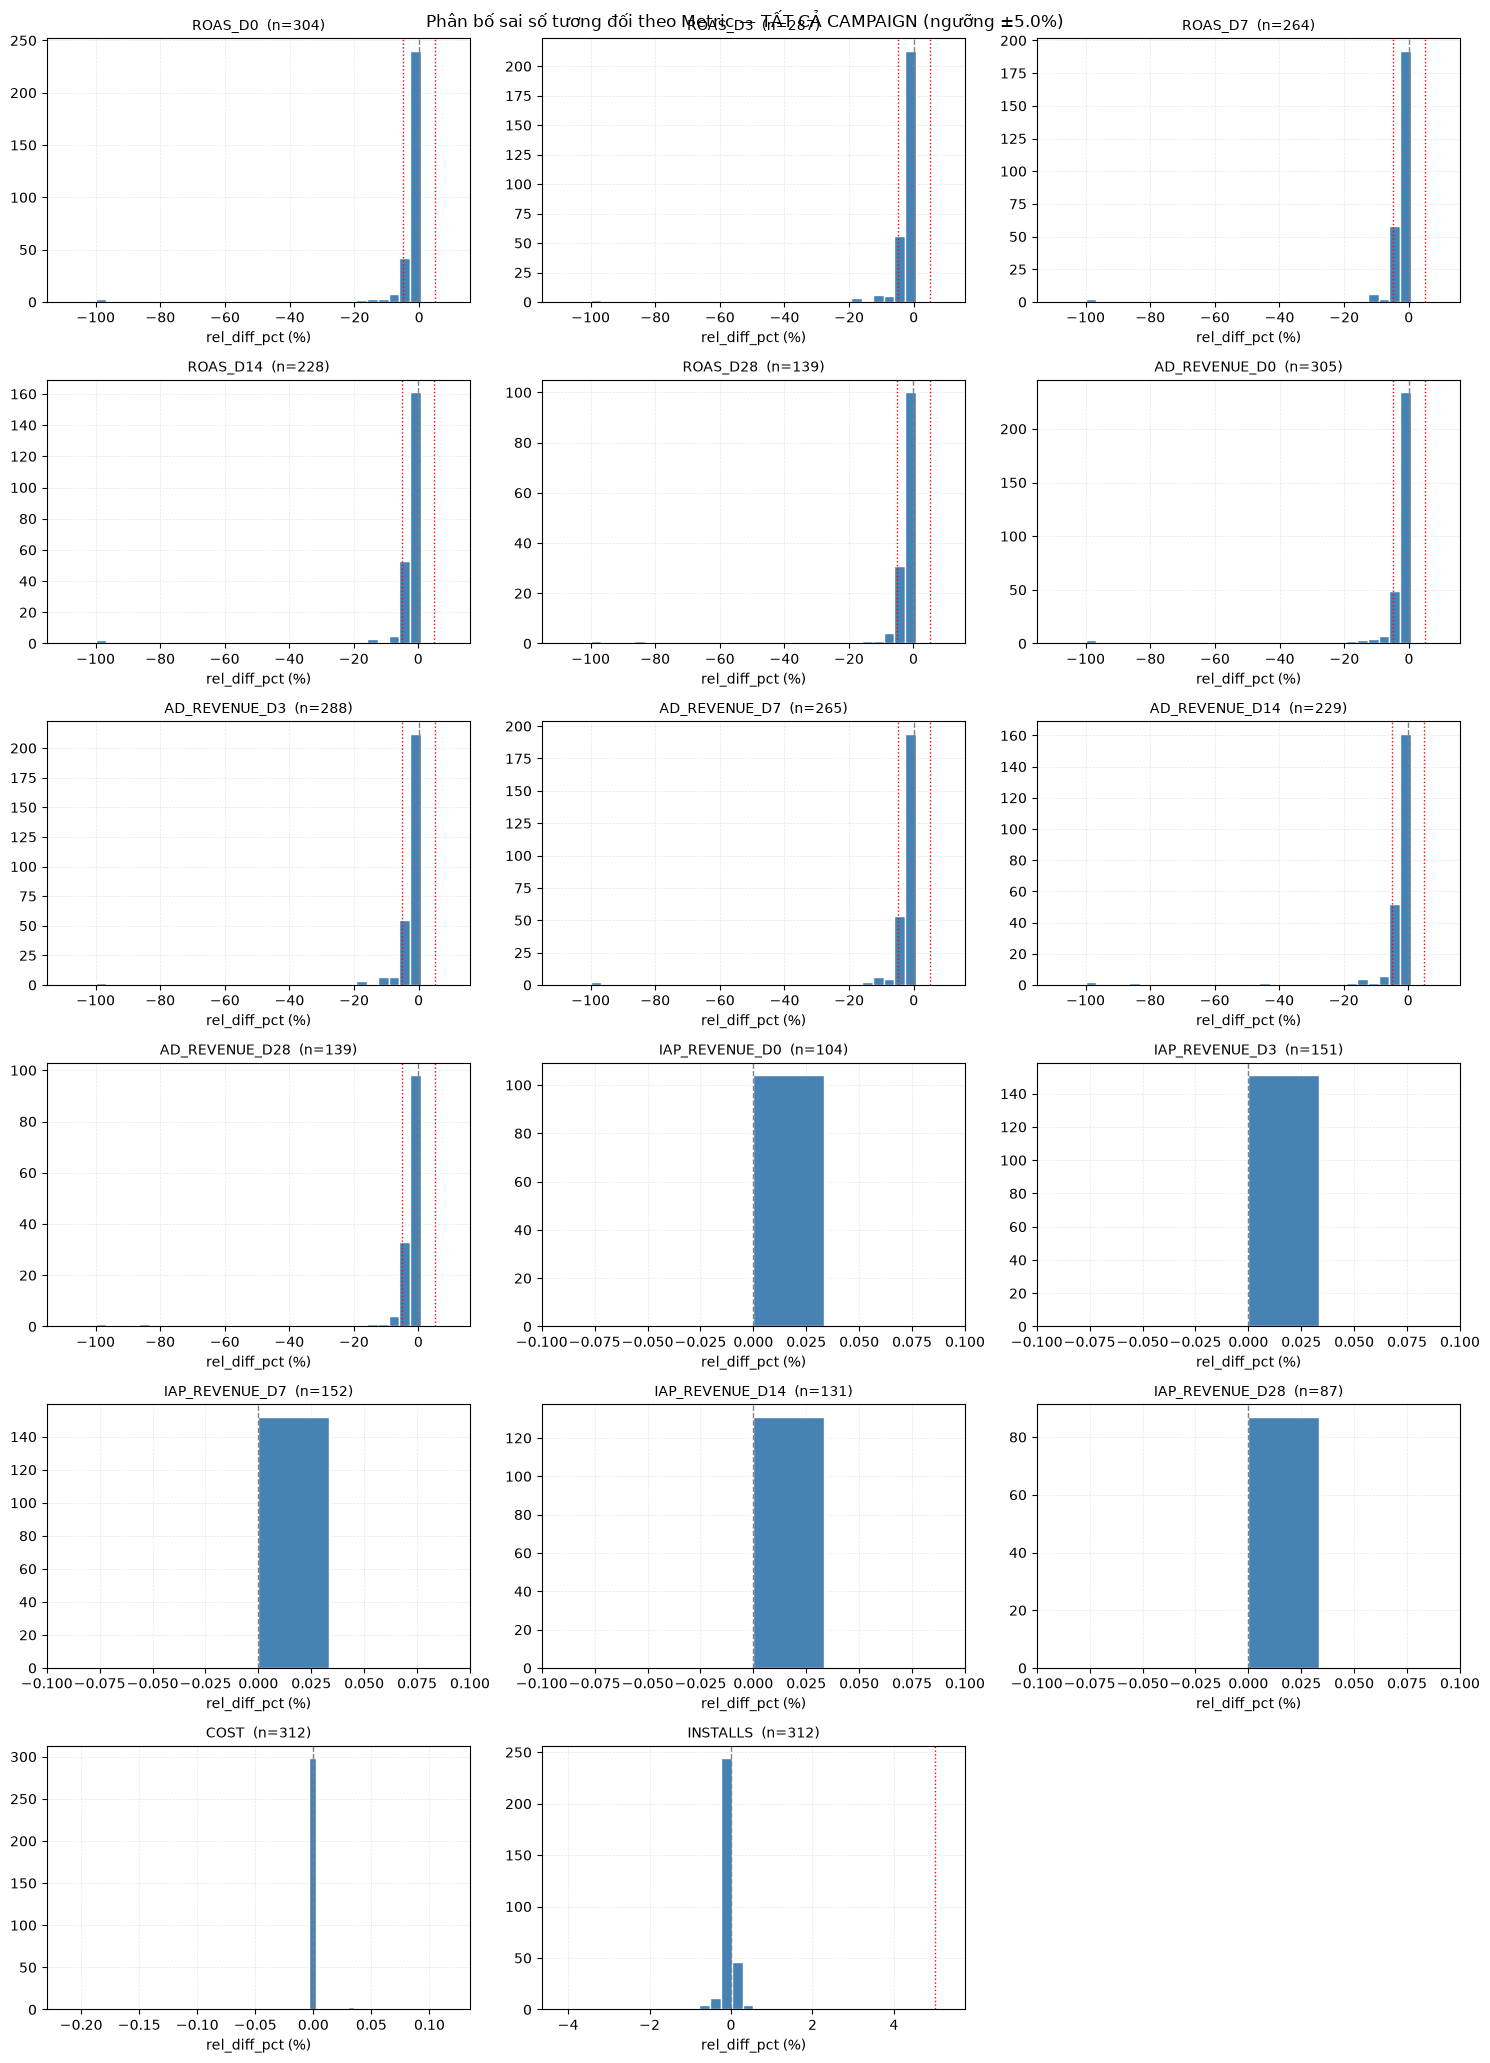

In [41]:
eda.plot_rel_diff_histogram(detail)

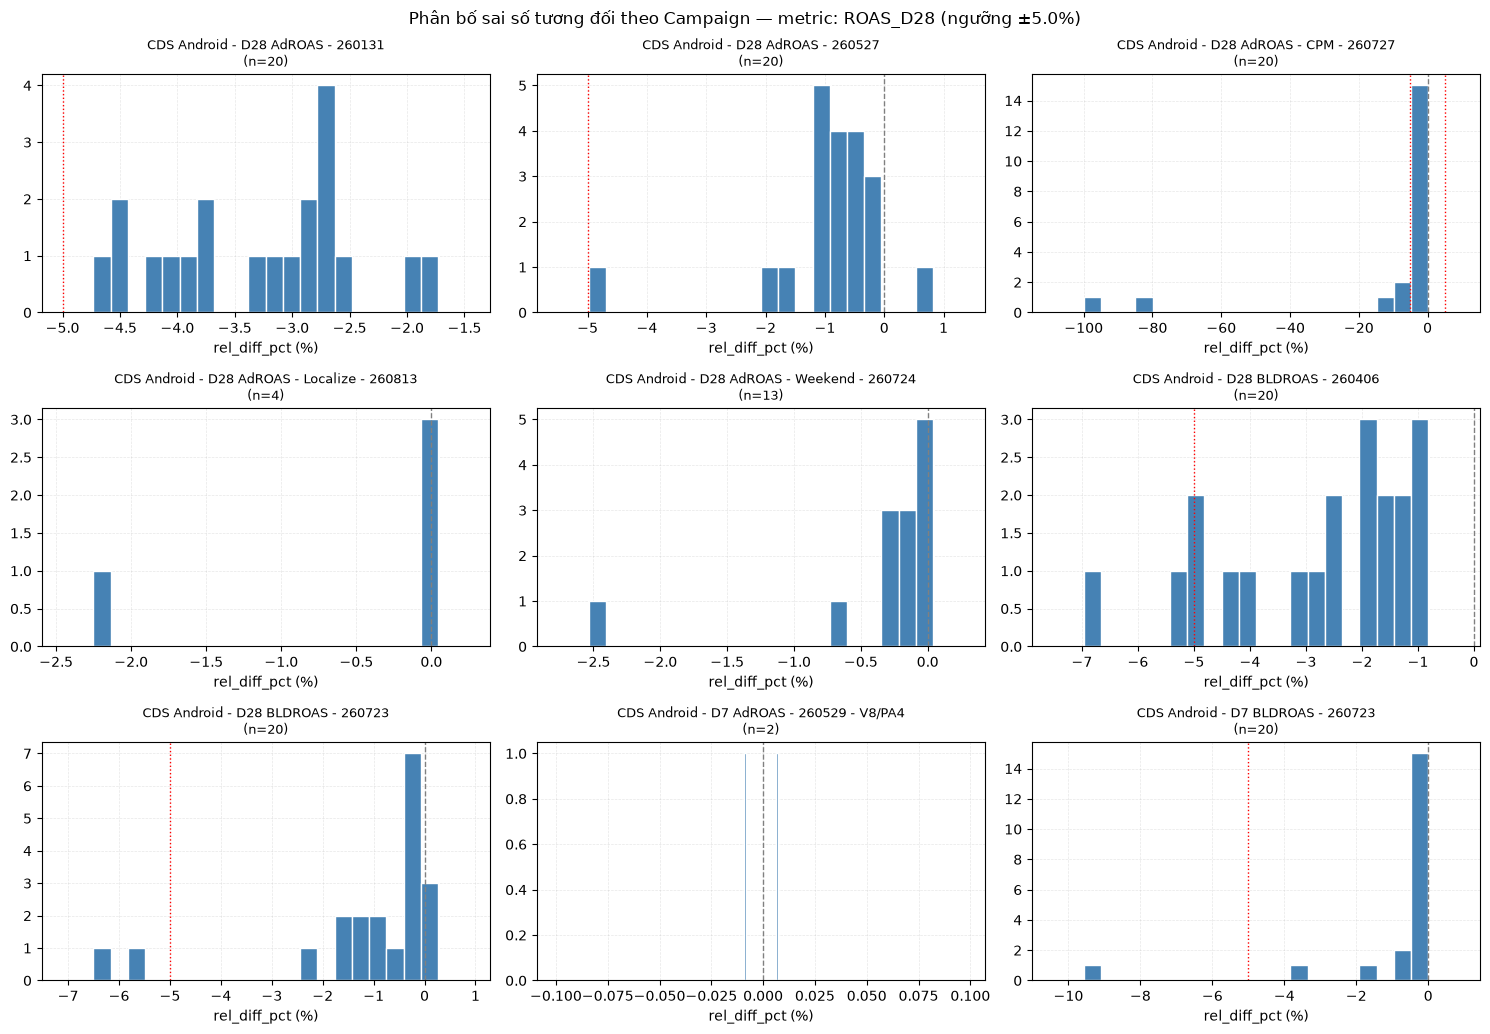

In [42]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

In [43]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

⚠️ Không tìm thấy dữ liệu hợp lệ cho campaign 'BCE Android - D28 AdROAS - 260813'. Kiểm tra lại tên campaign (VD: sorted(detail['campaign'].unique())).


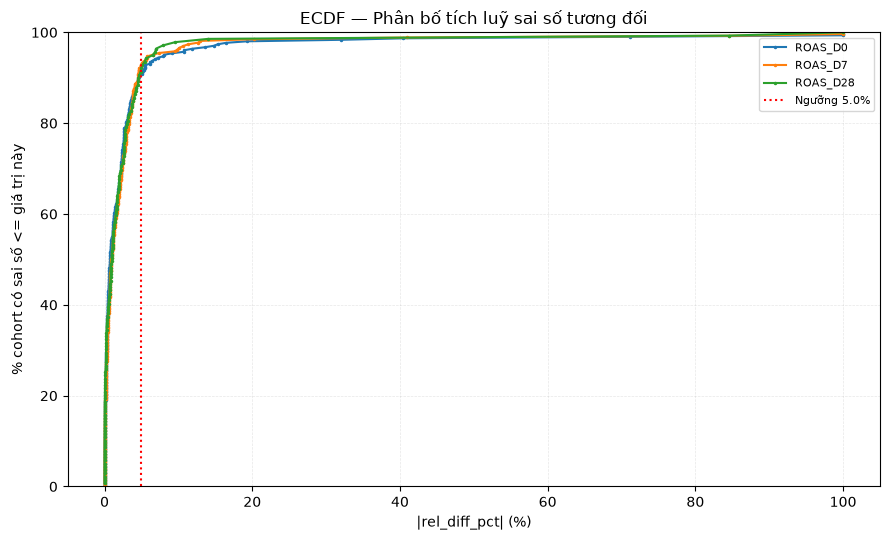

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 304                  90.5
 ROAS_D7 264                  92.8
ROAS_D28 139                  92.1


In [44]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [45]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
